# Exploring the dataset

This is an adapted notebook based on the "38-Cloud-Data preparation" Kaggle notebook by Mauricio Cordeiro (https://www.kaggle.com/code/cordmaur/38-cloud-data-preparation?scriptVersionId=31357028). Based upon 38-Cloud, the original version of the dataset before the 95-Cloud expansion.

It creates a custom PyTorch Dataset and Dataloader to handle the multi-band channels of the 38-Cloud dataset.

The dataset has 8,400 training patches of size 384x384. The patches are separated into red, green, blue, and Near Infrared (NIR) channels, with a ground truth mask. All are in separate directories.

Most semantic segmentation models are designed to work with RBG. To include NIR, a custom dataset class is created. It reads in the colour and NIR patches and combines them into a tensor.

## Checking if CUDA is available on this device

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

True
12.1
NVIDIA GeForce RTX 3050 Ti Laptop GPU


## Imports

In [1]:
from pathlib import Path
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

print(f"NumPy version: {np.__version__}")
print(f"Pillow version: {Image.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Pandas version: {pd.__version__}")

NumPy version: 2.3.3
Pillow version: 11.3.0


NameError: name 'torch' is not defined

## Custom CloudDataset class.

Maps the available files, returns the number of items using __len__()

Combines the 4 channels (red, green, blue, NIR) into one tensor. 

For a given index, return a tuple (x,y) with a sample from the dataset. X is the 4-channel tensor. Y is the ground truth mask. For this __getitem__() function is defined.

The class recieves the directories of each channel as input. Begins by mapping the files, combining the paths for all the bands into a directory.

Normalisation is applied to the pixel values. Better for training: all bands will be on a comparable scale.

In [3]:
class CloudDataset(Dataset):
    def __init__(self, r_dir, g_dir, b_dir, nir_dir, gt_dir, pytorch=True, include_nir=True):
        super().__init__()

        # loop through files in the red folder: being used as a reference list
        # combine the other bands into a dictionary
        r_dir = Path(r_dir)
        
        # collect only files with expected extension (filter out directories)
        red_files = sorted([f for f in r_dir.iterdir() if f.is_file()])
        
        # for every red file, create this list of dicts with ALL band paths
        self.files = [self.combine_files(f, g_dir, b_dir, nir_dir, gt_dir) for f in red_files]
        self.pytorch = pytorch
        self.include_nir = include_nir

    def combine_files(self, r_file: Path, g_dir, b_dir, nir_dir, gt_dir):
        # assume files have same naming structure
        name = r_file.name
        return {
            'red': r_file,
            'green': Path(g_dir) / name.replace('red', 'green'),
            'blue': Path(b_dir) / name.replace('red', 'blue'),
            'nir': Path(nir_dir) / name.replace('red', 'nir'),
            'gt': Path(gt_dir) / name.replace('red', 'gt')
        }

    def __len__(self):
        return len(self.files)

    #load image files, convert them to numeric arrays, stack the bands together
    def open_as_array(self, idx, invert=False):
        
        # read red/green/blue
        # each of these is a two-dimensional array (width x height)
        f = self.files[idx]
        r = np.array(Image.open(f['red']))
        g = np.array(Image.open(f['green']))
        b = np.array(Image.open(f['blue']))
        
        # each of them gets stacked into three-dimensional array rbg (width x height x 3)
        rgb = np.stack([r, g, b], axis=2)  # H, W, C (3)
        
        # optionally include the NIR channel
        if self.include_nir:
            try:
                nir = np.array(Image.open(f['nir']))
                nir = np.expand_dims(nir, axis=2)
                arr = np.concatenate([rgb, nir], axis=2)
            except FileNotFoundError:
                # fallback to just rgb if NIR missing
                arr = rgb
        else:
            arr = rgb

        # Normalise 
        # based on integer dtype (typical uint8)
        # makes all pixel values between 0 and 1
        if np.issubdtype(arr.dtype, np.integer):
            arr = arr.astype(np.float32) / np.iinfo(arr.dtype).max
        else:
            arr = arr.astype(np.float32)

        if invert:
            # Reorder the dimensions for PyTorch format: Channel, Height, Width
            arr = arr.transpose((2, 0, 1))
        return arr

    # convert mask to binary
    def open_mask(self, idx, add_channel_dim=False):
        f = self.files[idx]
        # mask is greyscale: 255 = cloud, 0 = not cloud
        mask = np.array(Image.open(f['gt']))
        # convert 255 to 1, everything else 0
        mask = np.where(mask == 255, 1, 0).astype(np.uint8)
        if add_channel_dim:
            return np.expand_dims(mask, axis=0)  # (1 x H x W) = 3D tensor with channel dimension
        else:
            return mask  # (H x W) = 2D image

    # get one training sample
    def __getitem__(self, idx):
        x_arr = self.open_as_array(idx, invert=self.pytorch)
        # tensor expects float for inputs
        x = torch.tensor(x_arr, dtype=torch.float32) # input image tensor (4 x H x W)
        y_arr = self.open_mask(idx, add_channel_dim=False) # cloud ground truth mask (H x W)
        # classification / segmentation mask should be long for loss functions
        y = torch.tensor(y_arr, dtype=torch.int64)
        return x, y

        # just extracts the RGB to convert back into normal image format
        # ignores NIR
    def open_as_pil(self, idx):
        arr = self.open_as_array(idx, invert=False)  # (H x W x C)
        rgb = arr[..., :3]
        rgb = (rgb * 255).astype(np.uint8)
        return Image.fromarray(rgb, mode='RGB')

    def __repr__(self):
        return f"CloudDataset with {len(self)} files (include_nir={self.include_nir})"

## Using the CloudDataset class to create a dataset object.

Links red, green, blue, NIR, and ground truth folders

A sample is loaded and printed to show the tensor and mask shape, and that mask values are formatted to be binary.

In [4]:
from pathlib import Path

base_path = Path(r"C:\Users\racha\OneDrive\Desktop\Dataset\38-Cloud_training")

data = CloudDataset(
    r_dir = base_path / 'train_red',
    g_dir = base_path / 'train_green',
    b_dir = base_path / 'train_blue',
    nir_dir = base_path / 'train_nir',
    gt_dir = base_path / 'train_gt',
    pytorch=True,
    include_nir=True
)
print(data)
x, y = data[333]
print("Input tensor shape (C, H, W):", x.shape)
print("Mask shape (H, W):", y.shape)
print("Unique mask values:", torch.unique(y))

CloudDataset with 8400 files (include_nir=True)
Input tensor shape (C, H, W): torch.Size([4, 384, 384])
Mask shape (H, W): torch.Size([384, 384])
Unique mask values: tensor([0, 1])


## Visualising the individual bands of one input tensor and its ground truth mask

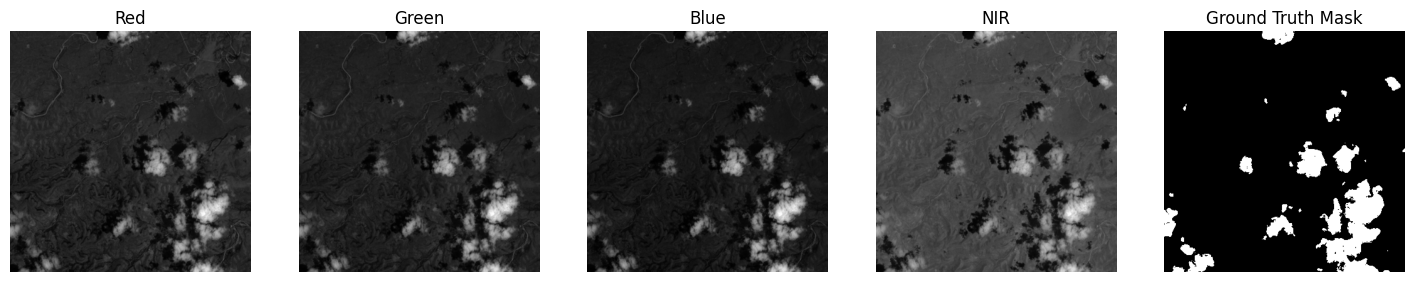

In [5]:
idx = 1111 # sample input tensor
x, y = data[idx]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

band_names = ["Red", "Green", "Blue", "NIR"]
for i in range(4):
    axes[i].imshow(x[i], cmap="gray")
    axes[i].set_title(band_names[i])
    axes[i].axis("off")

axes[4].imshow(y, cmap="gray")
axes[4].set_title("Ground Truth Mask")
axes[4].axis("off")

plt.show()


## Visualising the combined RGB image patch and its ground truth mask

x.shape (C,H,W): torch.Size([4, 384, 384])
y.shape (H,W): torch.Size([384, 384])


C:\Users\racha\AppData\Local\Temp\ipykernel_26604\407318924.py:97: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(rgb, mode='RGB')


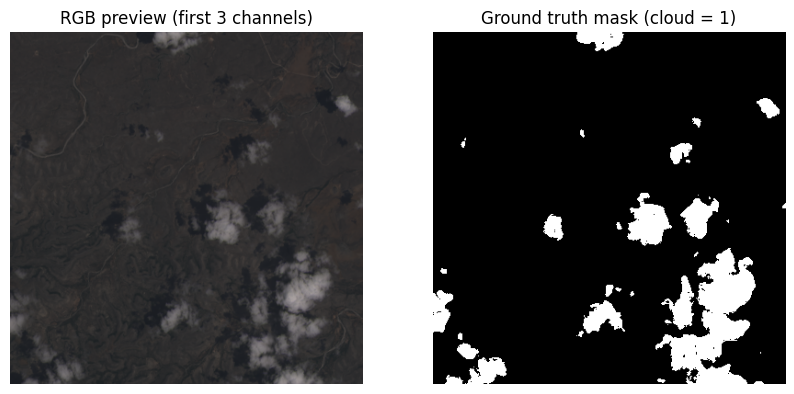

In [6]:
x, y = data[1111] # same as previous
print('x.shape (C,H,W):', x.shape)
print('y.shape (H,W):', y.shape)

# show image + mask
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].imshow(data.open_as_pil(1111))
ax[0].set_title('RGB preview (first 3 channels)')
ax[0].axis('off')

ax[1].imshow(data.open_mask(1111), cmap='gray')
ax[1].set_title('Ground truth mask (cloud = 1)')
ax[1].axis('off')
plt.show()


## Visualising on histograms the distribution of pixels for each band

Using a random sample of 50 patches.

The skew here is due to the number of patches which are all black: these are from patches being taken from the black margin around the Landsat 8 image. This will be addressed with the nonempty CSV file further down.

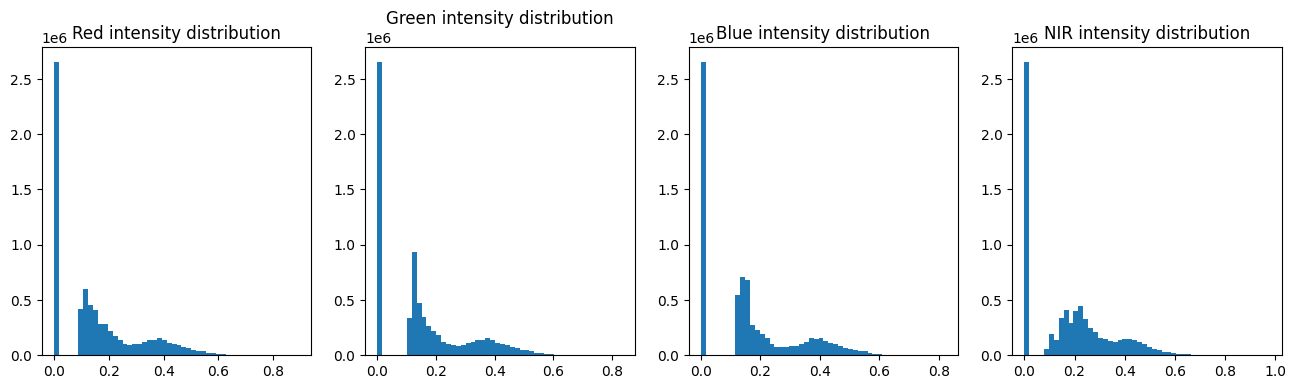

In [7]:
# Calculate and show the pixel intensity distribution per band
sample_indices = np.random.choice(len(data), size=50, replace=False) 

pixels = {i: [] for i in range(4)} # 4 channels
band_names = ["Red", "Green", "Blue", "NIR"]

for idx in sample_indices:
    x, _ = data[idx] # get input tensor (x) and mask (y)
    for band in range(4):
        pixels[band].append(x[band].flatten().numpy()) 
        # flatten converts 2D image into 1D array of pixel values
        # numpy converts from a pytorch tensor into a numpy array

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for band in range(4):
    all_pixels = np.concatenate(pixels[band]) # combine all arrays for that band
    axes[band].hist(all_pixels, bins=50)
    axes[band].set_title(f"{band_names[band]} intensity distribution")

plt.show()


## Calculating the average cloud cover

Only the ground truth cover is needed to do this.

For speed, a subset of size 500 is used.

<!-- This demonstrates one thing to note for this dataset: it is imbalanced. There is more not-cloud than cloud. -->

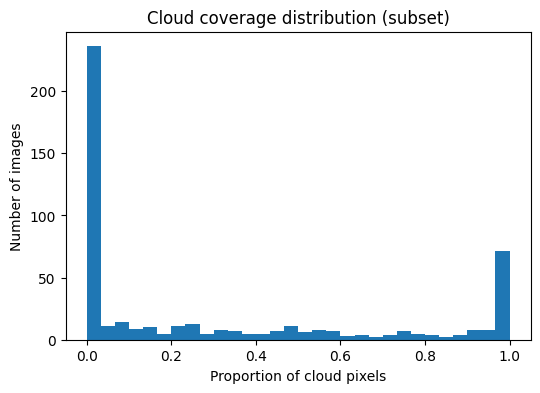

Mean cloud coverage: 0.3078905029296875


In [8]:
import random

num_samples = 500 
indices = random.sample(range(len(data)), num_samples)

cloud_ratios = []

for i in indices:
    mask = data.open_mask(i)
    cloud_ratio = mask.sum() / mask.size
    cloud_ratios.append(cloud_ratio)

plt.figure(figsize=(6,4))
plt.hist(cloud_ratios, bins=30)
plt.xlabel("Proportion of cloud pixels")
plt.ylabel("Number of images")
plt.title("Cloud coverage distribution (subset)")
plt.show()

print("Mean cloud coverage:", np.mean(cloud_ratios))


## Calculate the mean and standard deviation of each channel

Again, a subset is used for speed.

The pixel values are normalised to 0 - 1. Therefore the means here show that the patches are quite dark.

NIR is slightly higher: vegetation has high reflectance for NIR, so it shows as being brighter.

In [9]:

means = []
stds = []

for band in range(4):
    band_pixels = []
    for i in sample_indices:
        x, _ = data[i]
        band_pixels.append(x[band].flatten().numpy())
    band_pixels = np.concatenate(band_pixels)
    means.append(band_pixels.mean())
    stds.append(band_pixels.std())

for i, name in enumerate(["Red", "Green", "Blue", "NIR"]):
    print(f"{name}: mean={means[i]:.4f}, std={stds[i]:.4f}")

Red: mean=0.1542, std=0.1566
Green: mean=0.1521, std=0.1519
Blue: mean=0.1618, std=0.1594
NIR: mean=0.1755, std=0.1646


# The non-empty CSV

The dataset includes a CSV which lists the patches which have useful information. The Landsat 8 pictures, which the patches are extracted from, have black margins. This means some patches will be black, and so are not useful. The patches listed in the CSV are those which have less than 80% of black margin.

## Showing the contents of the CSV

It lists patch names: these can be prepended with "red_" etc. to provide the full file names of the corresponding channels.

In [10]:
csv_path = Path(r"C:\Users\racha\OneDrive\Desktop\Dataset\training_patches_38-cloud_nonempty.csv")
df_nonempty = pd.read_csv(csv_path)

print(df_nonempty.head(), len(df_nonempty))
print(f"Full name: ", df_nonempty.iloc[0, 0])

                                                name
0  patch_100_5_by_12_LC08_L1TP_061017_20160720_20...
1  patch_100_5_by_12_LC08_L1TP_063016_20160920_20...
2  patch_100_5_by_12_LC08_L1TP_064014_20160420_20...
3  patch_100_5_by_12_LC08_L1TP_064017_20160420_20...
4  patch_100_5_by_12_LC08_L1TP_066017_20160520_20... 5155
Full name:  patch_100_5_by_12_LC08_L1TP_061017_20160720_20170223_01_T1


## Extracting names of non-empty patches, calculating how many empty patches exist

In [11]:
valid_patches = set(df_nonempty['name'].astype(str))
print("Number of non-empty patches according to CSV:", len(valid_patches))

# Extract patch IDs from filenames
dataset_patches = []

for f in data.files:
    stem = f["red"].stem  # e.g. red_patch_...
    patch_name = stem.replace("red_", "")  # remove band prefix
    dataset_patches.append(patch_name)

dataset_patches = set(dataset_patches)

print("Total dataset patches:", len(dataset_patches))

empty_patches = dataset_patches - valid_patches

print("Non-empty patches:", len(valid_patches))
print("Empty patches:", len(empty_patches))


Number of non-empty patches according to CSV: 5155
Total dataset patches: 8400
Non-empty patches: 5155
Empty patches: 3245


## Using the array of non-empty patches to create a filtered dataset

In [12]:
filtered_files = []

for f in data.files:
    patch_name = f["red"].stem.replace("red_", "")
    if patch_name in valid_patches:
        filtered_files.append(f)

data_nonempty = CloudDataset(
    r_dir = base_path / 'train_red',
    g_dir = base_path / 'train_green',
    b_dir = base_path / 'train_blue',
    nir_dir = base_path / 'train_nir',
    gt_dir = base_path / 'train_gt',
    pytorch=True,
    include_nir=True
)

# overwrite files list
data_nonempty.files = filtered_files

print(len(data_nonempty))


5155


## Building index lists so empty vs non-empty can be compared

In [13]:
valid_patches = set(df_nonempty['name'].astype(str))

nonempty_indices = []
empty_indices = []

for i, f in enumerate(data.files):
    patch_name = f["red"].stem.replace("red_", "")
    if patch_name in valid_patches:
        nonempty_indices.append(i)
    else:
        empty_indices.append(i)

print("Non-empty patches: ", len(nonempty_indices))
print("Empty patches: ", len(empty_indices))

Non-empty patches:  5155
Empty patches:  3245


## Compare RBG previews from a random non-empty patch vs. a random empty patch

C:\Users\racha\AppData\Local\Temp\ipykernel_26604\407318924.py:97: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(rgb, mode='RGB')


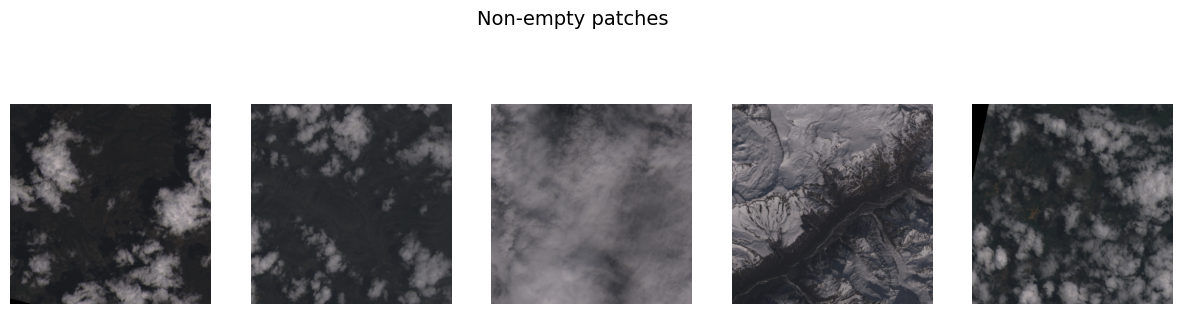

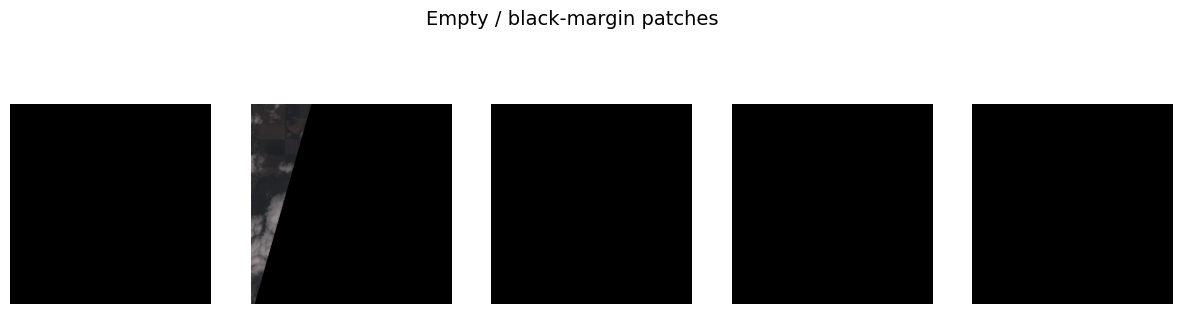

In [14]:
def show_examples(indices, title, n=5):
    fig, axes = plt.subplots(1, n, figsize=(15, 4))
    fig.suptitle(title, fontsize=14)

    for ax, idx in zip(axes, random.sample(indices, n)):
        img = data.open_as_pil(idx)
        ax.imshow(img)
        ax.axis("off")

    plt.show()

show_examples(nonempty_indices, "Non-empty patches")
show_examples(empty_indices, "Empty / black-margin patches")


## Visualisation of pixel intensity distribution

Shows how non-empty patches cluster around zero. Non-empty patches follow a more spread out normal distribution. 

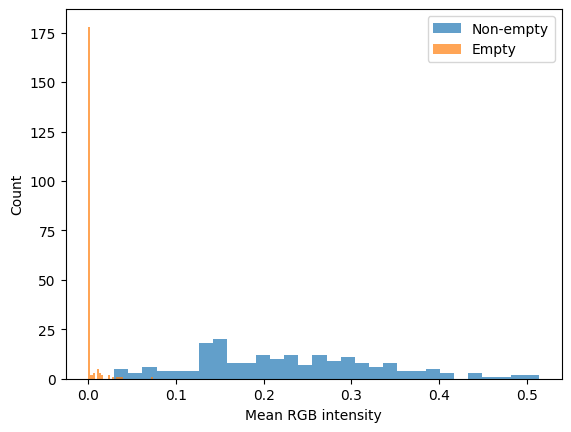

In [15]:
def mean_intensity(indices, n=200):
    vals = []
    for idx in random.sample(indices, n):
        arr = data.open_as_array(idx, invert=False)
        vals.append(arr[..., :3].mean())
    return np.array(vals)

nonempty_means = mean_intensity(nonempty_indices)
empty_means = mean_intensity(empty_indices)

plt.hist(nonempty_means, bins=30, alpha=0.7, label="Non-empty")
plt.hist(empty_means, bins=30, alpha=0.7, label="Empty")
plt.xlabel("Mean RGB intensity")
plt.ylabel("Count")
plt.legend()
plt.show()


## Showing the dataset size before and after filtering using the non-empty CSV 

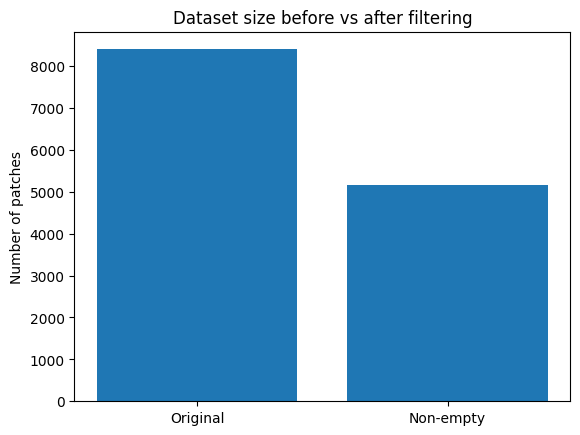

In [16]:
labels = ["Original", "Non-empty"]
sizes = [len(data), len(nonempty_indices)]

plt.bar(labels, sizes)
plt.ylabel("Number of patches")
plt.title("Dataset size before vs after filtering")
plt.show()


# Returning to the custom CloudDataset

The dataset is split into training and validation with a 70/30 split.

Usually test would be also included, with a split of around 70/15/15 - 80/10/10.

However, this dataset already provides a folder of testing patches.

In [17]:
# Splitting into training and validation with a 70/30 split
# usually test would be included, with a split of around 70/15/15 - 80/10/10
# this dataset includes testing patches, without ground truth masks, already
from torch.utils.data import random_split

total = len(data)
train_size = int(total * 0.7)
valid_size = total - train_size

train_ds, valid_ds = random_split(data, [train_size, valid_size])

train_dl = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)
valid_dl = DataLoader(valid_ds, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

# quick iteration test
xb, yb = next(iter(train_dl))
print('batch x shape:', xb.shape)


batch x shape: torch.Size([8, 4, 384, 384])


In [18]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
# gets a batch of input images. xb = input images, yb = masks
xb, yb = next(iter(train_dl))
# moves batch to the device
xb = xb.to(device)
yb = yb.to(device)
print('moved batch to device')


device: cuda
moved batch to device
